# Data

## Dataset Overview

In [1]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(rstatix)
library(pwr)
library(coin)
library(HDInterval)
source("config.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter


Loading required package: survival


Attaching package: ‘coin’


The following objects are masked from ‘package:rstatix’:

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




In [2]:
marketing.data <- read.csv(MARKETING_DATA)

str(marketing.data)

'data.frame':	588101 obs. of  7 variables:
 $ X            : int  0 1 2 3 4 5 6 7 8 9 ...
 $ user.id      : int  1069124 1119715 1144181 1435133 1015700 1137664 1116205 1496843 1448851 1446284 ...
 $ test.group   : chr  "ad" "ad" "ad" "ad" ...
 $ converted    : chr  "False" "False" "False" "False" ...
 $ total.ads    : int  130 93 21 355 276 734 264 17 21 142 ...
 $ most.ads.day : chr  "Monday" "Tuesday" "Tuesday" "Tuesday" ...
 $ most.ads.hour: int  20 22 18 10 14 10 13 18 19 14 ...


In [3]:
marketing.data$converted <- as.logical(toupper(marketing.data$converted))

day.levels <- c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")
marketing.data$most.ads.day <- factor(marketing.data$most.ads.day, levels = day.levels, ordered = TRUE)

marketing.data$test.group <- factor(marketing.data$test.group, levels = c("psa", "ad"))

summary(marketing.data)

       X             user.id        test.group   converted      
 Min.   :     0   Min.   : 900000   psa: 23524   Mode :logical  
 1st Qu.:147025   1st Qu.:1143190   ad :564577   FALSE:573258   
 Median :294050   Median :1313725                TRUE :14843    
 Mean   :294050   Mean   :1310692                               
 3rd Qu.:441075   3rd Qu.:1484088                               
 Max.   :588100   Max.   :1654483                               
                                                                
   total.ads          most.ads.day   most.ads.hour  
 Min.   :   1.00   Monday   :87073   Min.   : 0.00  
 1st Qu.:   4.00   Tuesday  :77479   1st Qu.:11.00  
 Median :  13.00   Wednesday:80908   Median :14.00  
 Mean   :  24.82   Thursday :82982   Mean   :14.47  
 3rd Qu.:  27.00   Friday   :92608   3rd Qu.:18.00  
 Max.   :2065.00   Saturday :81660   Max.   :23.00  
                   Sunday   :85391                  

In [4]:
missing.idx <- which(!complete.cases(marketing.data))
length(missing.idx)

[1] 0

# Exploratory Data Analysis

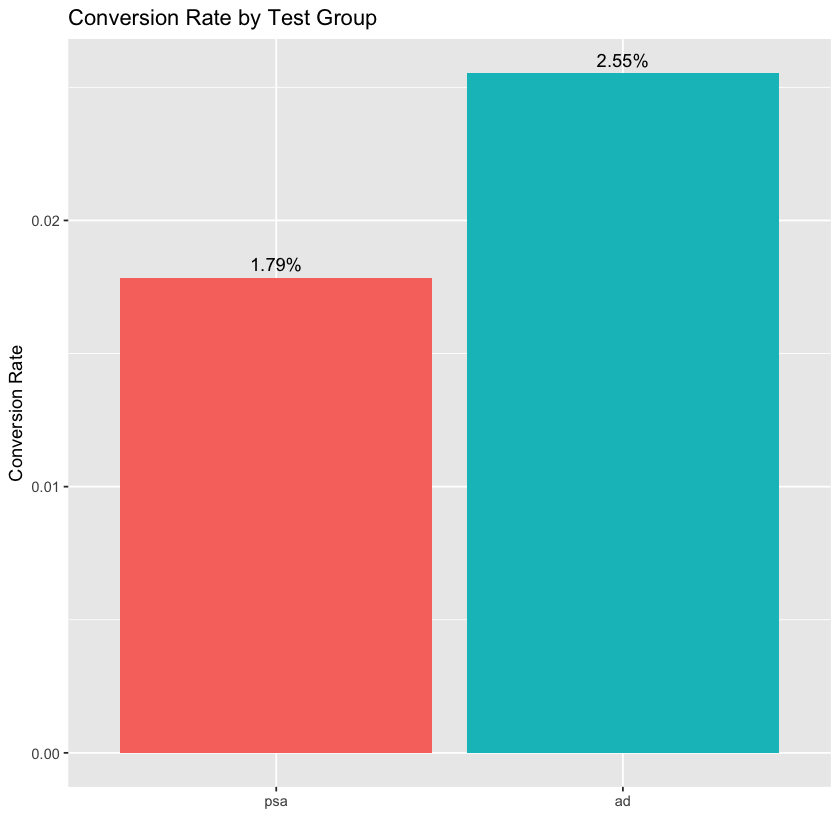

In [5]:
marketing.data %>%
  group_by(test.group) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = test.group, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = scales::percent(converted_rate, accuracy = 0.01)),
            vjust = -0.5) +
  labs(title = "Conversion Rate by Test Group",
       x = "", y = "Conversion Rate") +
  theme(legend.position = "none")


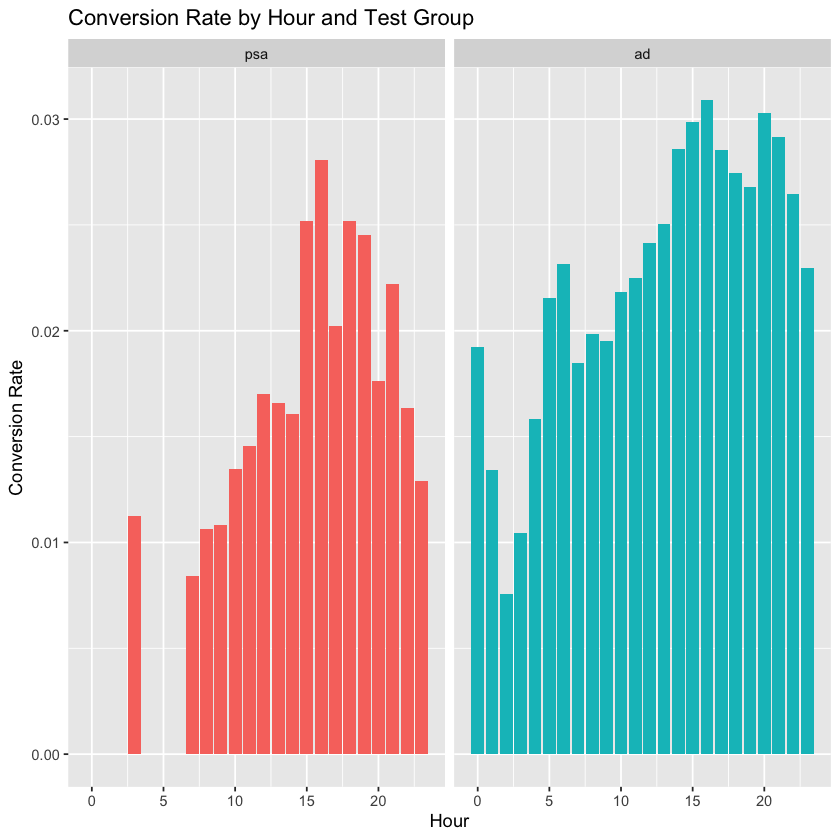

In [6]:
marketing.data %>%
  group_by(test.group, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  labs(title = "Conversion Rate by Hour and Test Group", x = "Hour", y = "Conversion Rate") +
  theme(legend.position = "none")

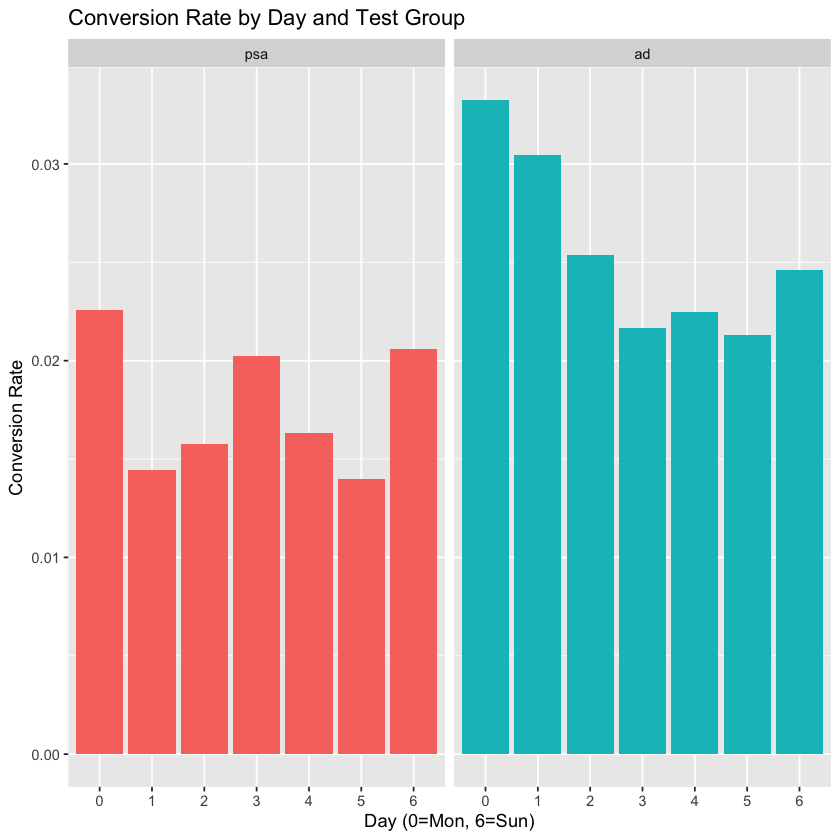

In [7]:
marketing.data %>%
  group_by(test.group, most.ads.day) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.day, y = converted_rate, fill = test.group)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ test.group) +
  scale_x_discrete(labels = 0:6) +
  labs(title = "Conversion Rate by Day and Test Group", x = "Day (0=Mon, 6=Sun)", y = "Conversion Rate") +
  theme(legend.position = "none")

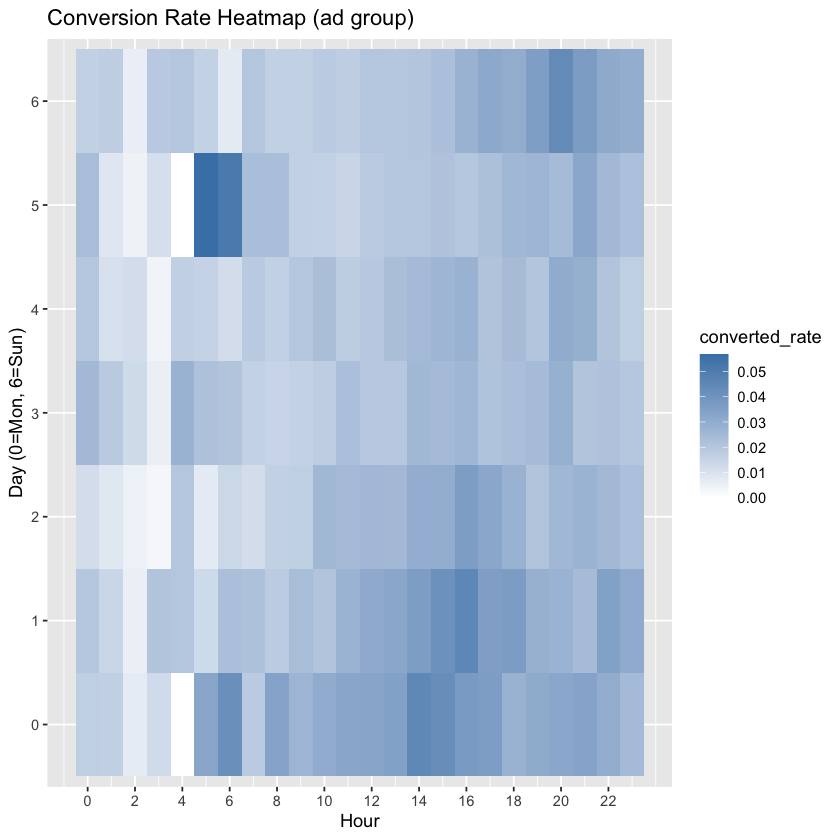

In [8]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day, most.ads.hour) %>%
  summarise(converted_rate = mean(converted), .groups = "drop") %>%
  ggplot(aes(x = most.ads.hour, y = most.ads.day, fill = converted_rate)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  scale_x_continuous(breaks = seq(0, 23, by = 2)) +
  scale_y_discrete(labels = 0:6) +
  labs(title = "Conversion Rate Heatmap (ad group)", x = "Hour", y = "Day (0=Mon, 6=Sun)")


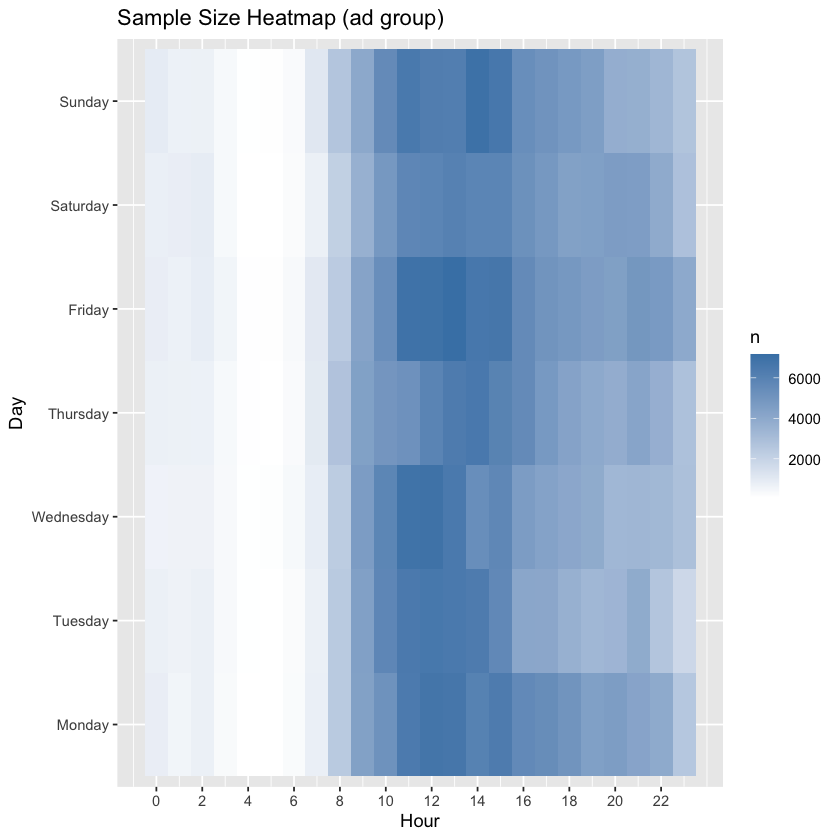

In [9]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day, most.ads.hour) %>%
  summarise(
    n = n(),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = most.ads.hour, y = most.ads.day, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "steelblue") +
  scale_x_continuous(breaks = seq(0, 23, by = 2)) +
  labs(title = "Sample Size Heatmap (ad group)", 
       x = "Hour", 
       y = "Day")

Lower bound: -65 
Upper bound: 96 
Number of outliers: 24825 
Percentage: 4.22 %


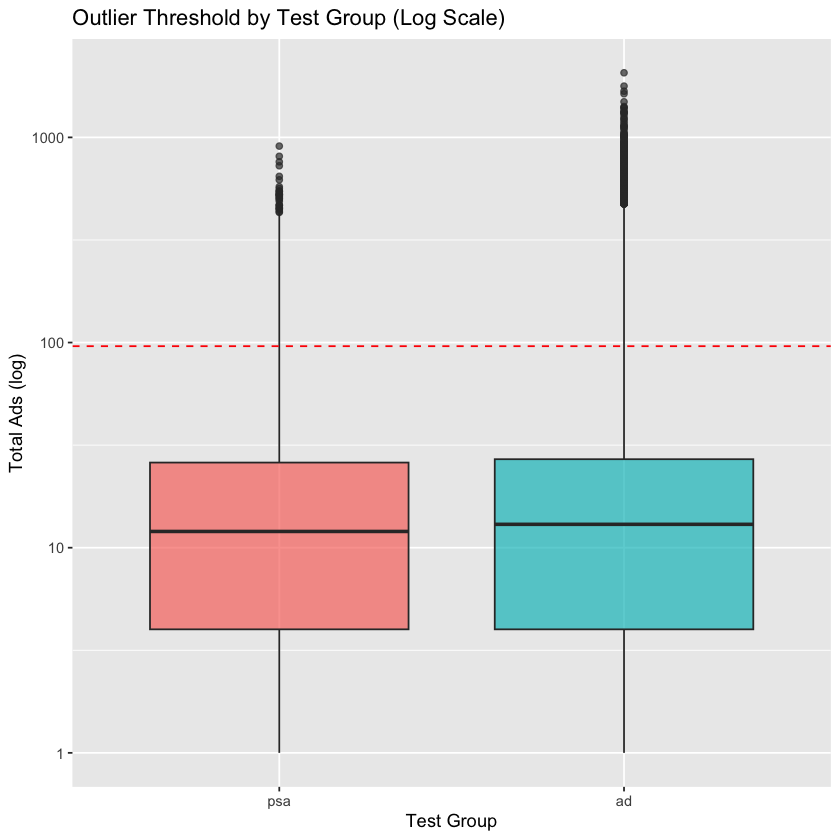

In [10]:
Q1 <- quantile(marketing.data$total.ads, 0.25)
Q3 <- quantile(marketing.data$total.ads, 0.75)
IQR_val <- Q3 - Q1

lower_bound <- Q1 - 3 * IQR_val
upper_bound <- Q3 + 3 * IQR_val

outliers <- marketing.data[marketing.data$total.ads > upper_bound, ]

cat("Lower bound:", lower_bound, "\n")
cat("Upper bound:", upper_bound, "\n")
cat("Number of outliers:", nrow(outliers), "\n")
cat("Percentage:", round(nrow(outliers) / nrow(marketing.data) * 100, 2), "%\n")

ggplot(marketing.data, aes(x = test.group, y = total.ads, fill = test.group)) +
  geom_boxplot(alpha = 0.7) +
  geom_hline(yintercept = upper_bound, color = "red", linetype = "dashed") +
  scale_y_log10() +
  labs(title = "Outlier Threshold by Test Group (Log Scale)",
       x = "Test Group", y = "Total Ads (log)") +
  theme(legend.position = "none")


In [11]:
marketing.data %>%
  mutate(is_outlier = total.ads > 96) %>%
  group_by(is_outlier, test.group) %>%
  summarise(converted_rate = mean(converted), .groups = "drop")%>%
  knitr::kable()




|is_outlier |test.group | converted_rate|
|:----------|:----------|--------------:|
|FALSE      |psa        |      0.0131080|
|FALSE      |ad         |      0.0191293|
|TRUE       |psa        |      0.1150685|
|TRUE       |ad         |      0.1718078|

# Frequentist A/B Testing

## Randomization Check（total.ads）

In [12]:
marketing.data %>%
  group_by(test.group) %>%
  summarise(
    mean = mean(total.ads),
    median = median(total.ads),
    variance = var(total.ads)
  )%>%
  knitr::kable()



|test.group |     mean| median| variance|
|:----------|--------:|------:|--------:|
|psa        | 24.76114|     12| 1837.041|
|ad         | 24.82337|     13| 1914.102|

In [13]:
result_total_ads <- wilcox.test(total.ads ~ test.group, data = marketing.data)

effect_total_ads <- wilcox_effsize(marketing.data, total.ads ~ test.group)

mw_results <- data.frame(
  metric          = "total.ads",
  W               = as.numeric(result_total_ads$statistic),
  p_value         = round(result_total_ads$p.value, 4),
  rank_biserial_r = round(effect_total_ads$effsize, 4),
  magnitude       = effect_total_ads$magnitude
)

print(mw_results, row.names = FALSE)

    metric          W p_value rank_biserial_r magnitude
 total.ads 6472821126       0          0.0086     small


## Primary Analysis（converted）

In [14]:
table.converted <- table(test.group = marketing.data$test.group, 
                         converted = marketing.data$converted)

result_converted <- prop.test(table.converted[, c("TRUE", "FALSE")])

print(result_converted)


	2-sample test for equality of proportions with continuity correction

data:  table.converted[, c("TRUE", "FALSE")]
X-squared = 54.006, df = 1, p-value = 1.999e-13
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.009456114 -0.005928792
sample estimates:
    prop 1     prop 2 
0.01785411 0.02554656 



### Effect size

In [15]:
p_psa <- result_converted$estimate[1]
p_ad  <- result_converted$estimate[2]

cohen_h <- ES.h(p_ad, p_psa)
cat("Cohen's h:", round(cohen_h, 4))

Cohen's h: 0.053

## Subgroup Analysis (ad group only)

### Conversion Rate by most.ads.day

#### Chi-Square Test & Effect Size by Day

In [16]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day) %>%
  summarise(
    n = n(),
    conversion_rate = mean(converted)
  ) %>%
  arrange(desc(conversion_rate)) %>%
  knitr::kable()



|most.ads.day |     n| conversion_rate|
|:------------|-----:|---------------:|
|Monday       | 83571|       0.0332412|
|Tuesday      | 74572|       0.0304404|
|Wednesday    | 77418|       0.0253559|
|Sunday       | 82332|       0.0246198|
|Friday       | 88805|       0.0224650|
|Thursday     | 79077|       0.0216371|
|Saturday     | 78802|       0.0213066|

In [17]:
chisq_day <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.day, .$converted)} %>%
  chisq.test()

print(chisq_day)


	Pearson's Chi-squared test

data:  .
X-squared = 412.79, df = 6, p-value < 2.2e-16



In [18]:
chisq_day$residuals %>% knitr::kable()



|          |      FALSE|       TRUE|
|:---------|----------:|----------:|
|Monday    | -2.2533848| 13.9171304|
|Tuesday   | -1.3538026|  8.3612207|
|Wednesday |  0.0537514| -0.3319737|
|Thursday  |  1.1136712| -6.8781452|
|Friday    |  0.9302841| -5.7455279|
|Saturday  |  1.2057390| -7.4467647|
|Sunday    |  0.2693742| -1.6636819|

In [19]:
cramer_day <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.day, .$converted)} %>%
  cramer_v()

cat("Cramér's V:", round(cramer_day, 4))

Cramér's V: 0.027

#### Pairwise Comparison of Conversion Rate by most.ads.day (Bonferroni Correction)

In [20]:
day_summary <- marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.day) %>%
  summarise(
    n = n(),
    converted = sum(converted)
  ) %>%
  arrange(most.ads.day)

pairwise.prop.test(
  x = day_summary$converted,
  n = day_summary$n,
  p.adjust.method = "bonferroni"
)


	Pairwise comparisons using Pairwise comparison of proportions 

data:  day_summary$converted out of day_summary$n 

  1       2       3       4       5       6      
2 0.03446 -       -       -       -       -      
3 < 2e-16 4.0e-08 -       -       -       -      
4 < 2e-16 < 2e-16 2.7e-05 -       -       -      
5 < 2e-16 < 2e-16 0.00258 1.00000 -       -      
6 < 2e-16 < 2e-16 2.6e-06 1.00000 1.00000 -      
7 < 2e-16 4.1e-11 1.00000 0.00153 0.07253 0.00021

P value adjustment method: bonferroni 

### Conversion Rate by most.ads.hour

#### Chi-Square Test & Effect Size by Hour

In [21]:
marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.hour) %>%
  summarise(
    n = n(),
    conversion_rate = sum(converted) / n()
  ) %>%
  arrange(desc(conversion_rate)) %>%
  knitr::kable()



| most.ads.hour|     n| conversion_rate|
|-------------:|-----:|---------------:|
|            16| 35963|       0.0308929|
|            20| 27846|       0.0302736|
|            15| 42855|       0.0298448|
|            21| 28895|       0.0291746|
|            14| 43779|       0.0285753|
|            17| 33605|       0.0285374|
|            18| 31052|       0.0274701|
|            19| 29169|       0.0268093|
|            22| 25515|       0.0264550|
|            13| 45485|       0.0250632|
|            12| 45238|       0.0241390|
|             6|  1985|       0.0231738|
|            23| 19547|       0.0229703|
|            11| 44149|       0.0224694|
|            10| 37454|       0.0218401|
|             5|   742|       0.0215633|
|             8| 16968|       0.0198609|
|             9| 29802|       0.0195289|
|             0|  5309|       0.0192127|
|             7|  6168|       0.0184825|
|             4|   694|       0.0158501|
|             1|  4615|       0.0134345|
|             

In [22]:
chisq_hour <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.hour, .$converted)} %>%
  chisq.test()

print(chisq_hour)


	Pearson's Chi-squared test

data:  .
X-squared = 403.33, df = 23, p-value < 2.2e-16



In [23]:
chisq_hour$residuals %>% knitr::kable()



|   |      FALSE|       TRUE|
|:--|----------:|----------:|
|0  |  0.4675167| -2.8874301|
|1  |  0.8335372| -5.1480094|
|2  |  1.3071245| -8.0729321|
|3  |  0.7796043| -4.8149144|
|4  |  0.2587679| -1.5981765|
|5  |  0.1099146| -0.6788436|
|6  |  0.1070910| -0.6614045|
|7  |  0.5620133| -3.4710505|
|8  |  0.7502647| -4.6337100|
|9  |  1.0523748| -6.4995724|
|10 |  0.7266496| -4.4878607|
|11 |  0.6549903| -4.0452855|
|12 |  0.3032763| -1.8730650|
|13 |  0.1044280| -0.6449579|
|14 | -0.6419789|  3.9649262|
|15 | -0.9013916|  5.5670846|
|16 | -1.0270721|  6.3433003|
|17 | -0.5554149|  3.4302982|
|18 | -0.3433636|  2.1206483|
|19 | -0.2184684|  1.3492830|
|20 | -0.7990879|  4.9352472|
|21 | -0.6247448|  3.8584864|
|22 | -0.1470030|  0.9079055|
|23 |  0.3648825| -2.2535510|

In [24]:
cramer_hour <- marketing.data %>%
  filter(test.group == "ad") %>%
  {table(.$most.ads.hour, .$converted)} %>%
  cramer_v()

cat("Cramér's V:", round(cramer_hour, 4))

Cramér's V: 0.0267

#### Pairwise Comparison of Conversion Rate by most.ads.hour (Bonferroni Correction)

In [25]:
hour_summary <- marketing.data %>%
  filter(test.group == "ad") %>%
  group_by(most.ads.hour) %>%
  summarise(
    n = n(),
    converted = sum(converted),
    conversion_rate =sum(converted) / n()
  ) %>%
  slice_max(conversion_rate, n = 10) %>%
  arrange(most.ads.hour)

result_pairwise_hour <- pairwise.prop.test(
  x = hour_summary$converted,
  n = hour_summary$n,
  p.adjust.method = "bonferroni"
)

rownames(result_pairwise_hour$p.value) <- as.character(hour_summary$most.ads.hour[-1])
colnames(result_pairwise_hour$p.value) <- as.character(hour_summary$most.ads.hour[-nrow(hour_summary)])

result_pairwise_hour


	Pairwise comparisons using Pairwise comparison of proportions 

data:  hour_summary$converted out of hour_summary$n 

   13      14      15      16      17      18      19      20      21     
14 0.05605 -       -       -       -       -       -       -       -      
15 0.00067 1.00000 -       -       -       -       -       -       -      
16 2.3e-05 1.00000 1.00000 -       -       -       -       -       -      
17 0.12866 1.00000 1.00000 1.00000 -       -       -       -       -      
18 1.00000 1.00000 1.00000 0.42357 1.00000 -       -       -       -      
19 1.00000 1.00000 0.78785 0.09908 1.00000 1.00000 -       -       -      
20 0.00121 1.00000 1.00000 1.00000 1.00000 1.00000 0.62561 -       -      
21 0.03391 1.00000 1.00000 1.00000 1.00000 1.00000 1.00000 1.00000 -      
22 1.00000 1.00000 0.48604 0.06103 1.00000 1.00000 1.00000 0.39064 1.00000

P value adjustment method: bonferroni 

# Bayesian A/B Testing

## Helper Functions

In [26]:
run_beta_binomial <- function(tbl, group, alpha_prior = 1, beta_prior = 1) {
  success <- tbl[group, "TRUE"]
  total   <- sum(tbl[group, ])
  list(
    alpha_post = alpha_prior + success,
    beta_post  = beta_prior  + total - success
  )
}

sample_beta_posterior <- function(bb, n_samples = 100000) {
  rbeta(n_samples, bb$alpha_post, bb$beta_post)
}

In [27]:
run_gamma_poisson <- function(data, group, alpha_prior = 1, beta_prior = 1) {
  ads <- data$total.ads[data$test.group == group]
  list(
    alpha_post = alpha_prior + sum(ads),
    beta_post  = beta_prior  + length(ads)
  )
}

sample_gamma_posterior <- function(gp, n_samples = 100000) {
  rgamma(n_samples, gp$alpha_post, gp$beta_post)
}

In [28]:
compare_posteriors <- function(samples_a, samples_b, label_a = "ad", label_b = "psa") {
  p_better <- mean(samples_a > samples_b)
  diff     <- samples_a - samples_b
  hdi_diff <- hdi(diff, credMass = 0.95)
  invisible(list(p_better = p_better, hdi_lower = hdi_diff[1], hdi_upper = hdi_diff[2]))
}

make_posterior_df <- function(x, params_a, params_b, 
                              label_a = "ad", label_b = "psa",
                              dist = "beta") {
  density_fn <- if (dist == "beta") dbeta else dgamma
  data.frame(
    x       = rep(x, 2),
    density = c(density_fn(x, params_a$alpha_post, params_a$beta_post),
                density_fn(x, params_b$alpha_post, params_b$beta_post)),
    group   = rep(c(label_a, label_b), each = length(x))
  )
}

In [29]:
make_bayesian_results <- function(metric_name, results) {
  data.frame(
    metric      = metric_name,
    p_ad_better = round(results$p_better, 4),
    hdi_lower   = round(results$hdi_lower, 4),
    hdi_upper   = round(results$hdi_upper, 4)
  )
}

In [30]:
run_bayesian_subgroup <- function(data, group_col, levels_vec = NULL,
                                   group_filter = "ad", seed = 42) {
  tbl <- data %>%
    filter(test.group == group_filter) %>%
    {table(.[[group_col]], .[["converted"]])}
  
  if (is.null(levels_vec)) levels_vec <- rownames(tbl)
  
  bb <- lapply(levels_vec, function(g) run_beta_binomial(tbl, g))
  names(bb) <- levels_vec
  
  set.seed(seed)
  samples <- lapply(levels_vec, function(g) sample_beta_posterior(bb[[g]]))
  names(samples) <- levels_vec
  
  list(levels = levels_vec, tbl = tbl, bb = bb, samples = samples)
}

make_posterior_summary <- function(result, group_col) {
  do.call(rbind, lapply(result$levels, function(g) {
    s <- result$samples[[g]]
    data.frame(
      group          = g,
      posterior_mean = round(mean(s), 4),
      hdi_lower      = round(hdi(s)[1], 4),
      hdi_upper      = round(hdi(s)[2], 4)
    )
  })) %>%
    rename(!!group_col := group) %>%
    knitr::kable(row.names = FALSE)
}

## Randomization Check（total.ads：Gamma-Poisson）

In [31]:
gp_ad  <- run_gamma_poisson(marketing.data, "ad")
gp_psa <- run_gamma_poisson(marketing.data, "psa")

set.seed(42)
samples_gp_ad  <- sample_gamma_posterior(gp_ad)
samples_gp_psa <- sample_gamma_posterior(gp_psa)

gp_results <- compare_posteriors(samples_gp_ad, samples_gp_psa)

make_bayesian_results("total.ads", gp_results)%>%
  knitr::kable(row.names = FALSE)



|metric    | p_ad_better| hdi_lower| hdi_upper|
|:---------|-----------:|---------:|---------:|
|total.ads |      0.9719|   -0.0013|    0.1284|

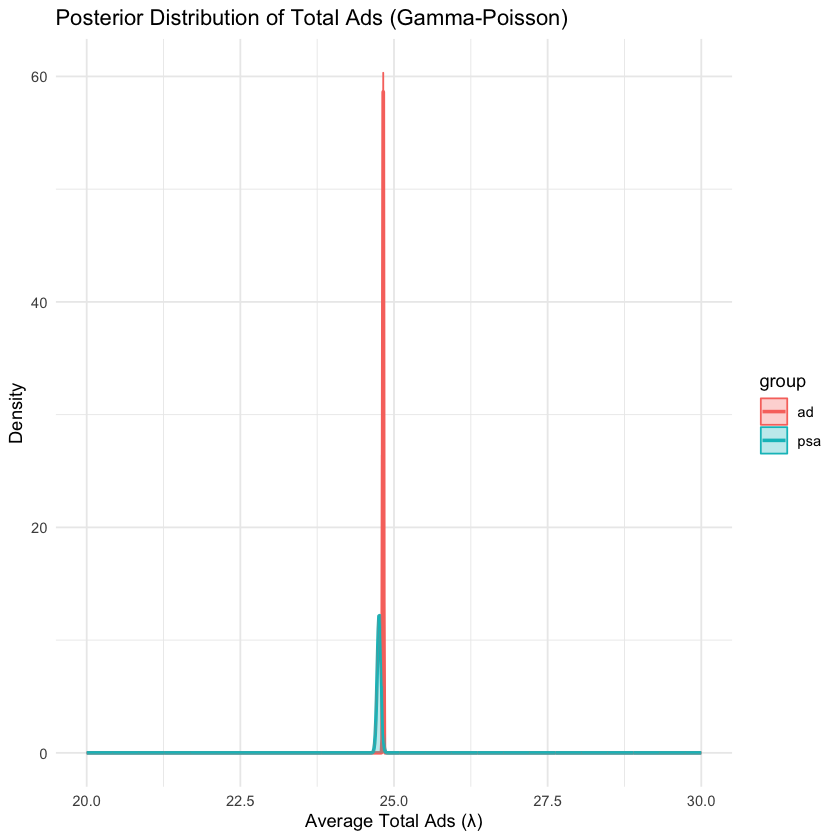

In [32]:
lambda_range <- seq(20, 30, length.out = 1000)

df_plot_gp <- make_posterior_df(lambda_range, gp_ad, gp_psa, dist = "gamma")

ggplot(df_plot_gp, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of Total Ads (Gamma-Poisson)",
       x = "Average Total Ads (λ)",
       y = "Density") +
       theme_minimal()

##  Primary Analysis（converted：Beta-Binomial）

In [33]:
tbl <- table(marketing.data$test.group, marketing.data$converted)

bb_ad  <- run_beta_binomial(tbl, "ad")
bb_psa <- run_beta_binomial(tbl, "psa")

set.seed(42)
samples_ad  <- sample_beta_posterior(bb_ad)
samples_psa <- sample_beta_posterior(bb_psa)

bb_results <- compare_posteriors(samples_ad, samples_psa)

make_bayesian_results("converted", bb_results) %>%
  knitr::kable(row.names = FALSE)



|metric    | p_ad_better| hdi_lower| hdi_upper|
|:---------|-----------:|---------:|---------:|
|converted |           1|    0.0059|    0.0094|

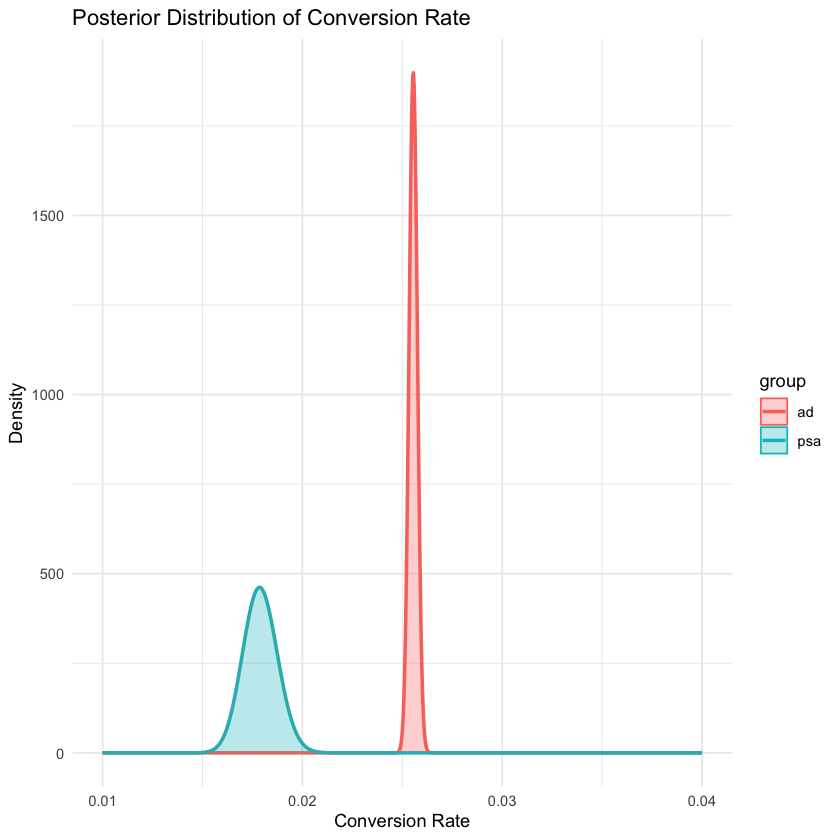

In [34]:
x <- seq(0.01, 0.04, length.out = 1000)

df_plot <- make_posterior_df(x, bb_ad, bb_psa)

ggplot(df_plot, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution of Conversion Rate",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()

## Subgroup Analysis (ad group only)

### Conversion Rate by most.ads.day

#### Posterior Distribution by Day

In [35]:
day_result <- run_bayesian_subgroup(marketing.data, "most.ads.day")

make_posterior_summary(day_result, "day")



|day       | posterior_mean| hdi_lower| hdi_upper|
|:---------|--------------:|---------:|---------:|
|Monday    |         0.0333|    0.0320|    0.0345|
|Tuesday   |         0.0305|    0.0292|    0.0317|
|Wednesday |         0.0254|    0.0243|    0.0265|
|Thursday  |         0.0217|    0.0207|    0.0227|
|Friday    |         0.0225|    0.0215|    0.0234|
|Saturday  |         0.0213|    0.0203|    0.0223|
|Sunday    |         0.0246|    0.0236|    0.0257|

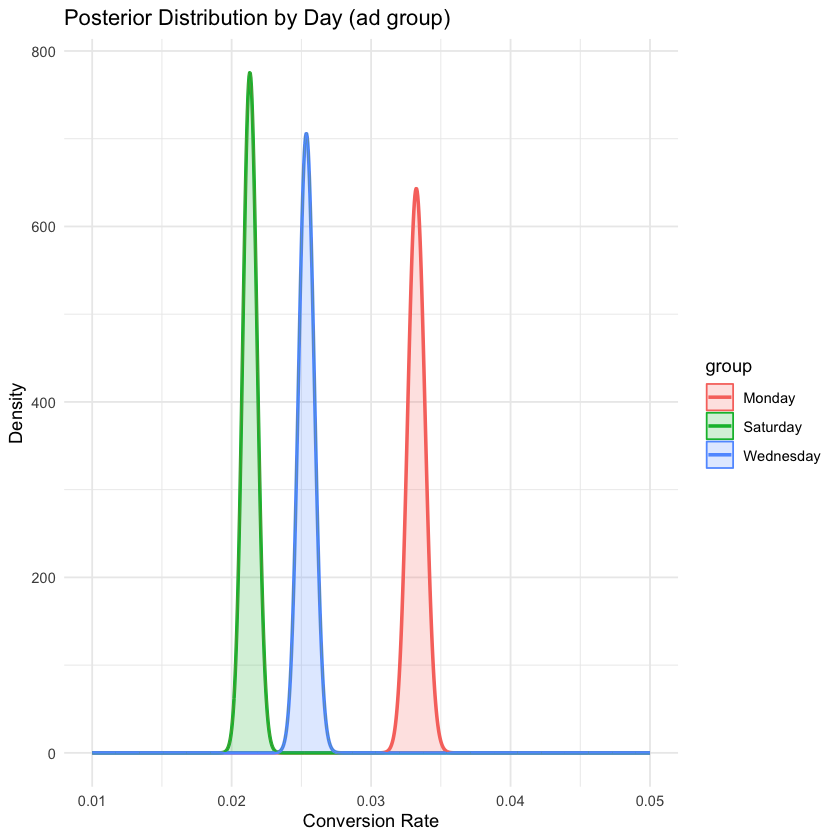

In [36]:
selected_days <- c("Monday", "Wednesday", "Saturday")

x <- seq(0.01, 0.05, length.out = 1000)

df_plot_day <- do.call(rbind, lapply(selected_days, function(d) {
  data.frame(
    x       = x,
    density = dbeta(x, day_result$bb[[d]]$alpha_post, day_result$bb[[d]]$beta_post),
    group   = d
  )
}))

ggplot(df_plot_day, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.2) +
  labs(title = "Posterior Distribution by Day (ad group)",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()

#### Pairwise Posterior Comparison by most.ads.day

In [37]:
results_day <- do.call(rbind, lapply(day_result$levels, function(a) {
  do.call(rbind, lapply(day_result$levels, function(b) {
    if (which(day_result$levels == a) >= which(day_result$levels == b)) return(NULL)
    res <- compare_posteriors(day_result$samples[[a]], day_result$samples[[b]],
                              label_a = a, label_b = b)
    make_bayesian_results(paste(a, "vs", b), res)
  }))
}))

knitr::kable(results_day, row.names = FALSE)



|metric                | p_ad_better| hdi_lower| hdi_upper|
|:---------------------|-----------:|---------:|---------:|
|Monday vs Tuesday     |      0.9993|    0.0011|    0.0045|
|Monday vs Wednesday   |      1.0000|    0.0062|    0.0095|
|Monday vs Thursday    |      1.0000|    0.0100|    0.0132|
|Monday vs Friday      |      1.0000|    0.0092|    0.0123|
|Monday vs Saturday    |      1.0000|    0.0103|    0.0135|
|Monday vs Sunday      |      1.0000|    0.0070|    0.0102|
|Tuesday vs Wednesday  |      1.0000|    0.0034|    0.0067|
|Tuesday vs Thursday   |      1.0000|    0.0072|    0.0104|
|Tuesday vs Friday     |      1.0000|    0.0064|    0.0095|
|Tuesday vs Saturday   |      1.0000|    0.0076|    0.0107|
|Tuesday vs Sunday     |      1.0000|    0.0042|    0.0075|
|Wednesday vs Thursday |      1.0000|    0.0022|    0.0052|
|Wednesday vs Friday   |      0.9999|    0.0014|    0.0044|
|Wednesday vs Saturday |      1.0000|    0.0025|    0.0055|
|Wednesday vs Sunday   |      0.8284| 

### Conversion Rate by most.ads.hour

#### Posterior Distribution by Hour

In [38]:
top_hours <- hour_summary %>%
  arrange(desc(conversion_rate)) %>%
  slice(1:10) %>%
  pull(most.ads.hour) %>%
  as.character()

best_hour <- hour_summary %>%
  arrange(desc(conversion_rate)) %>%
  slice(1) %>%
  pull(most.ads.hour) %>%
  as.character()

hour_result <- run_bayesian_subgroup(marketing.data, "most.ads.hour",
                                     levels_vec = top_hours)

make_posterior_summary(hour_result, "hour")



|hour | posterior_mean| hdi_lower| hdi_upper|
|:----|--------------:|---------:|---------:|
|16   |         0.0309|    0.0291|    0.0327|
|20   |         0.0303|    0.0283|    0.0323|
|15   |         0.0299|    0.0283|    0.0315|
|21   |         0.0292|    0.0272|    0.0311|
|14   |         0.0286|    0.0270|    0.0302|
|17   |         0.0286|    0.0268|    0.0304|
|18   |         0.0275|    0.0257|    0.0293|
|19   |         0.0268|    0.0250|    0.0287|
|22   |         0.0265|    0.0245|    0.0285|
|13   |         0.0251|    0.0237|    0.0265|

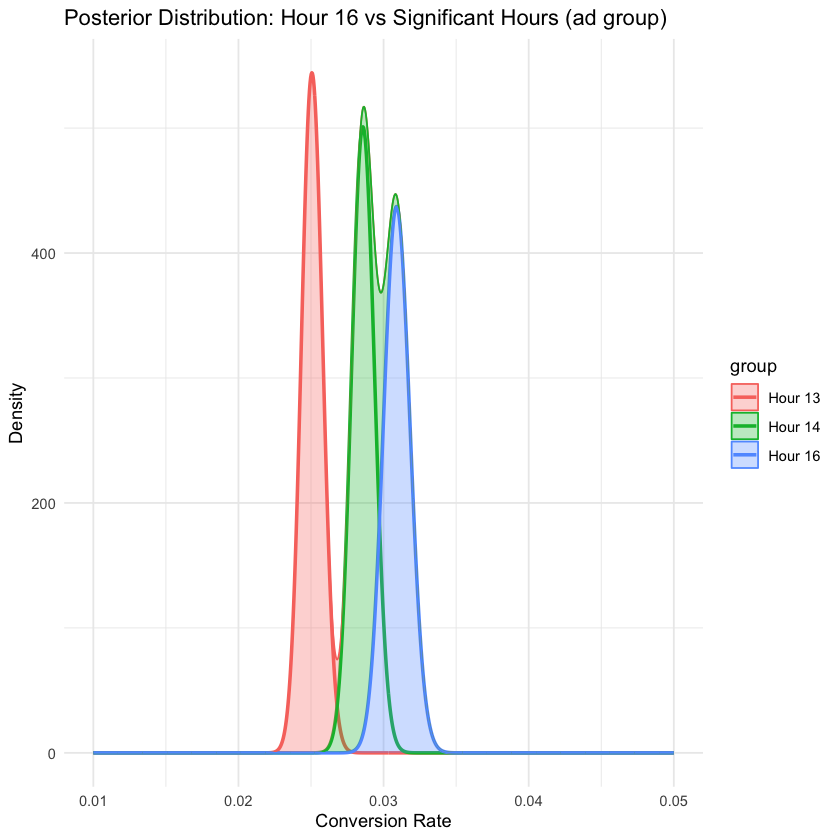

In [39]:
selected_hours <- c("13", "14", "16")

df_plot_hour_best <- do.call(rbind, lapply(selected_hours, function(h) {
  data.frame(
    x       = x,
    density = dbeta(x, hour_result$bb[[h]]$alpha_post, hour_result$bb[[h]]$beta_post),
    group   = paste("Hour", h)
  )
}))

ggplot(df_plot_hour_best, aes(x = x, y = density, fill = group, color = group)) +
  geom_line(linewidth = 1) +
  geom_area(alpha = 0.3) +
  labs(title = "Posterior Distribution: Hour 16 vs Significant Hours (ad group)",
       x = "Conversion Rate",
       y = "Density") +
  theme_minimal()

#### Pairwise Posterior Comparison by most.ads.hour (Hour 16 vs Significant Hours)

In [40]:
results_hour_best <- do.call(rbind, lapply(hour_result$levels, function(b) {
  if (best_hour == b) return(NULL)
  res <- compare_posteriors(hour_result$samples[[best_hour]], hour_result$samples[[b]],
                            label_a = best_hour, label_b = b)
  make_bayesian_results(paste("Hour", best_hour, "vs", b), res)
}))

knitr::kable(results_hour_best, row.names = FALSE)



|metric        | p_ad_better| hdi_lower| hdi_upper|
|:-------------|-----------:|---------:|---------:|
|Hour 16 vs 20 |      0.6703|   -0.0021|    0.0033|
|Hour 16 vs 15 |      0.8046|   -0.0013|    0.0035|
|Hour 16 vs 21 |      0.8979|   -0.0009|    0.0044|
|Hour 16 vs 14 |      0.9712|    0.0000|    0.0047|
|Hour 16 vs 17 |      0.9667|   -0.0002|    0.0049|
|Hour 16 vs 18 |      0.9957|    0.0008|    0.0060|
|Hour 16 vs 19 |      0.9990|    0.0015|    0.0067|
|Hour 16 vs 22 |      0.9993|    0.0017|    0.0071|
|Hour 16 vs 13 |      1.0000|    0.0036|    0.0082|